# Pertemuan 4 — Statistika Dasar & Analisis Data

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


In [1]:
NAMA      = "Novan Frido Saputro"
NIM       = "240401010119"
PRODI     = "Informatika"
ANGKATAN  = 2024
PERTEMUAN = 4

print("=" * 55)
print("  Pengantar Data Science")
print(f"  Pertemuan {PERTEMUAN} — Statistika Dasar & Analisis Data")
print("=" * 55)
print(f"  Nama     : {NAMA}")
print(f"  NIM      : {NIM}")
print(f"  Prodi    : {PRODI}")
print("=" * 55)

  Pengantar Data Science
  Pertemuan 4 — Statistika Dasar & Analisis Data
  Nama     : Novan Frido Saputro
  NIM      : 240401010119
  Prodi    : Informatika


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")

✅ Semua library berhasil diimport!
   pandas  : 2.2.2
   numpy   : 2.0.2
   seaborn : 0.13.2


In [3]:
print("=" * 55)
print("  LANGKAH 1 — LOAD & INSPECT DATASET")
print("=" * 55)

df = sns.load_dataset('iris')

print(f"\n📊 Shape dataset  : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"\n--- Tipe Data ---")
print(df.dtypes)
print(f"\n--- 5 Baris Pertama ---")
print(df.head())
print(f"\n--- Jumlah per Spesies ---")
print(df['species'].value_counts())
print(f"\n--- Statistik Deskriptif Awal ---")
print(df.describe().round(3))

  LANGKAH 1 — LOAD & INSPECT DATASET

📊 Shape dataset  : 150 baris × 5 kolom

--- Tipe Data ---
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

--- 5 Baris Pertama ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Jumlah per Spesies ---
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

--- Statistik Deskriptif Awal ---
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436 

In [4]:
print("=" * 55)
print("  LANGKAH 2 — STATISTIK DESKRIPTIF LENGKAP")
print("=" * 55)

kolom_numerik = df.select_dtypes(include='number').columns

for nama_kolom in kolom_numerik:
    col = df[nama_kolom]
    Q1  = col.quantile(0.25)
    Q2  = col.quantile(0.50)
    Q3  = col.quantile(0.75)
    IQR = Q3 - Q1

    print(f"\n{'='*45}")
    print(f"  Kolom: {nama_kolom}")
    print(f"{'='*45}")
    print(f"  Count    : {col.count()}")
    print(f"  Mean     : {col.mean():.3f}")
    print(f"  Median   : {col.median():.3f}")
    print(f"  Modus    : {col.mode()[0]:.3f}")
    print(f"  Std Dev  : {col.std():.3f}")
    print(f"  Varians  : {col.var():.3f}")
    print(f"  Min      : {col.min():.3f}")
    print(f"  Max      : {col.max():.3f}")
    print(f"  Range    : {col.max() - col.min():.3f}")
    print(f"  Q1 (25%) : {Q1:.3f}")
    print(f"  Q2 (50%) : {Q2:.3f}")
    print(f"  Q3 (75%) : {Q3:.3f}")
    print(f"  IQR      : {IQR:.3f}")

    skew = col.skew()
    print(f"  Skewness : {skew:.3f}  ", end="")
    if   skew < -1:    print("→ Miring kiri kuat")
    elif skew < -0.5:  print("→ Miring kiri moderat")
    elif skew <= 0.5:  print("→ Simetris / normal")
    elif skew <= 1:    print("→ Miring kanan moderat")
    else:              print("→ Miring kanan kuat")

    kurt = col.kurt()
    print(f"  Kurtosis : {kurt:.3f}  ", end="")
    if   kurt > 0:   print("→ Leptokurtic (ekor tebal)")
    elif kurt == 0:  print("→ Mesokurtic (normal)")
    else:            print("→ Platykurtic (ekor tipis)")

print(f"\n✅ Statistik deskriptif selesai!")

  LANGKAH 2 — STATISTIK DESKRIPTIF LENGKAP

  Kolom: sepal_length
  Count    : 150
  Mean     : 5.843
  Median   : 5.800
  Modus    : 5.000
  Std Dev  : 0.828
  Varians  : 0.686
  Min      : 4.300
  Max      : 7.900
  Range    : 3.600
  Q1 (25%) : 5.100
  Q2 (50%) : 5.800
  Q3 (75%) : 6.400
  IQR      : 1.300
  Skewness : 0.315  → Simetris / normal
  Kurtosis : -0.552  → Platykurtic (ekor tipis)

  Kolom: sepal_width
  Count    : 150
  Mean     : 3.057
  Median   : 3.000
  Modus    : 3.000
  Std Dev  : 0.436
  Varians  : 0.190
  Min      : 2.000
  Max      : 4.400
  Range    : 2.400
  Q1 (25%) : 2.800
  Q2 (50%) : 3.000
  Q3 (75%) : 3.300
  IQR      : 0.500
  Skewness : 0.319  → Simetris / normal
  Kurtosis : 0.228  → Leptokurtic (ekor tebal)

  Kolom: petal_length
  Count    : 150
  Mean     : 3.758
  Median   : 4.350
  Modus    : 1.400
  Std Dev  : 1.765
  Varians  : 3.116
  Min      : 1.000
  Max      : 6.900
  Range    : 5.900
  Q1 (25%) : 1.600
  Q2 (50%) : 4.350
  Q3 (75%) : 5.10

  LANGKAH 3 — DISTRIBUSI (HISTOGRAM + KDE)


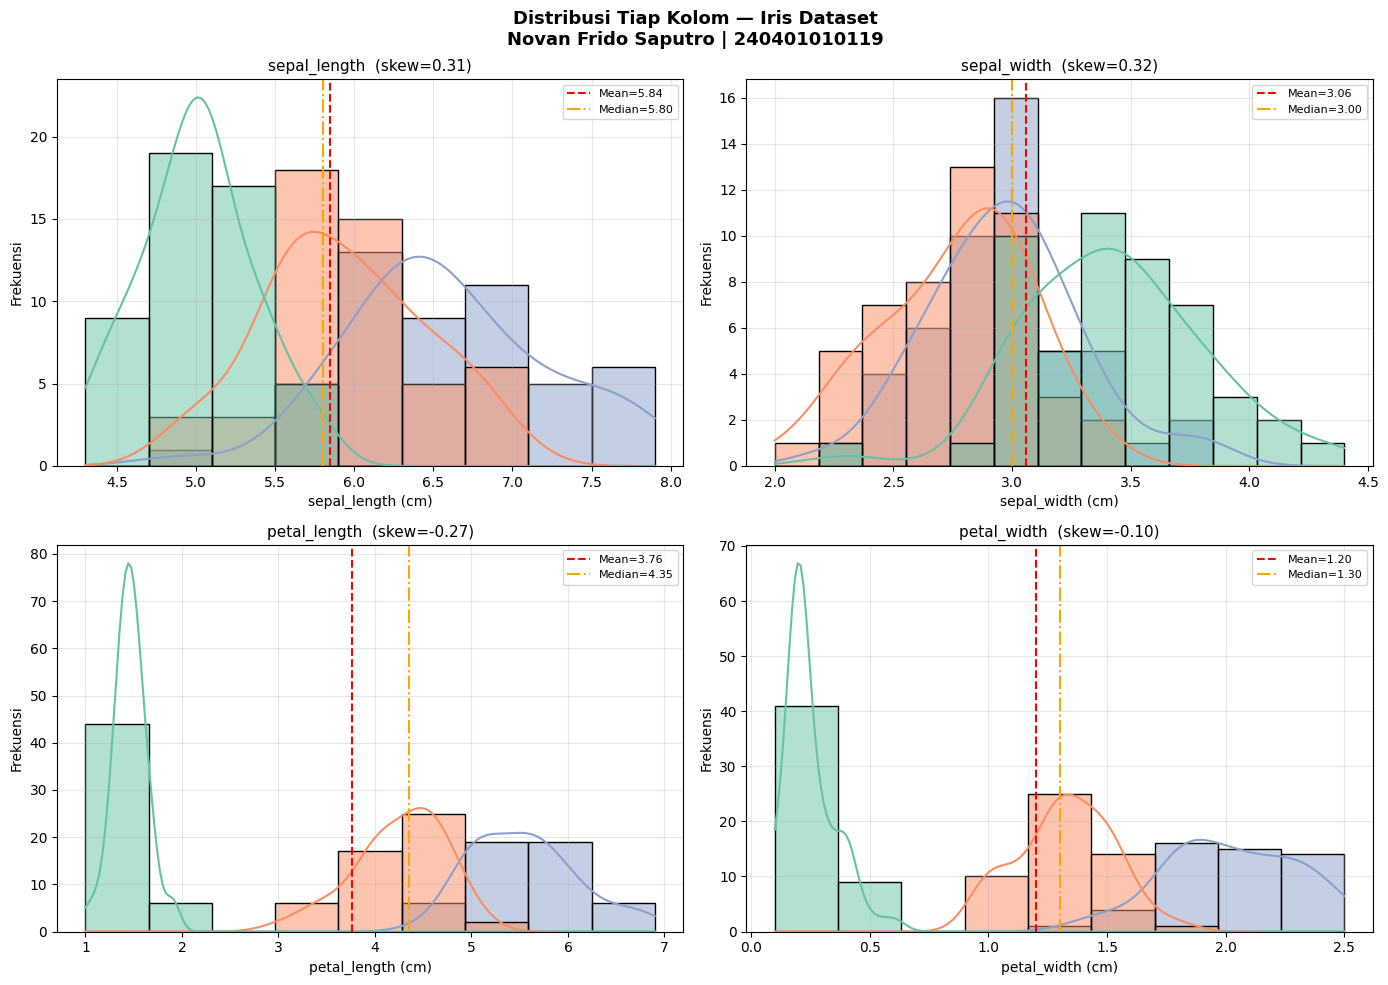

✅ Grafik disimpan: distribusi_iris.png


In [5]:
print("=" * 55)
print("  LANGKAH 3 — DISTRIBUSI (HISTOGRAM + KDE)")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Distribusi Tiap Kolom — Iris Dataset\n{NAMA} | {NIM}",
             fontsize=13, fontweight='bold')

for i, nama_kolom in enumerate(kolom_numerik):
    ax  = axes.flatten()[i]
    col = df[nama_kolom]

    sns.histplot(data=df, x=nama_kolom, hue='species',
                 kde=True, palette='Set2', alpha=0.5, ax=ax)

    mean_val   = col.mean()
    median_val = col.median()
    ax.axvline(mean_val,   color='red',    linestyle='--',
               linewidth=1.5, label=f'Mean={mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='-.',
               linewidth=1.5, label=f'Median={median_val:.2f}')

    ax.set_title(f"{nama_kolom}  (skew={col.skew():.2f})", fontsize=11)
    ax.set_xlabel(f"{nama_kolom} (cm)")
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi_iris.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: distribusi_iris.png")

  LANGKAH 4 — BOXPLOT & VIOLIN PLOT


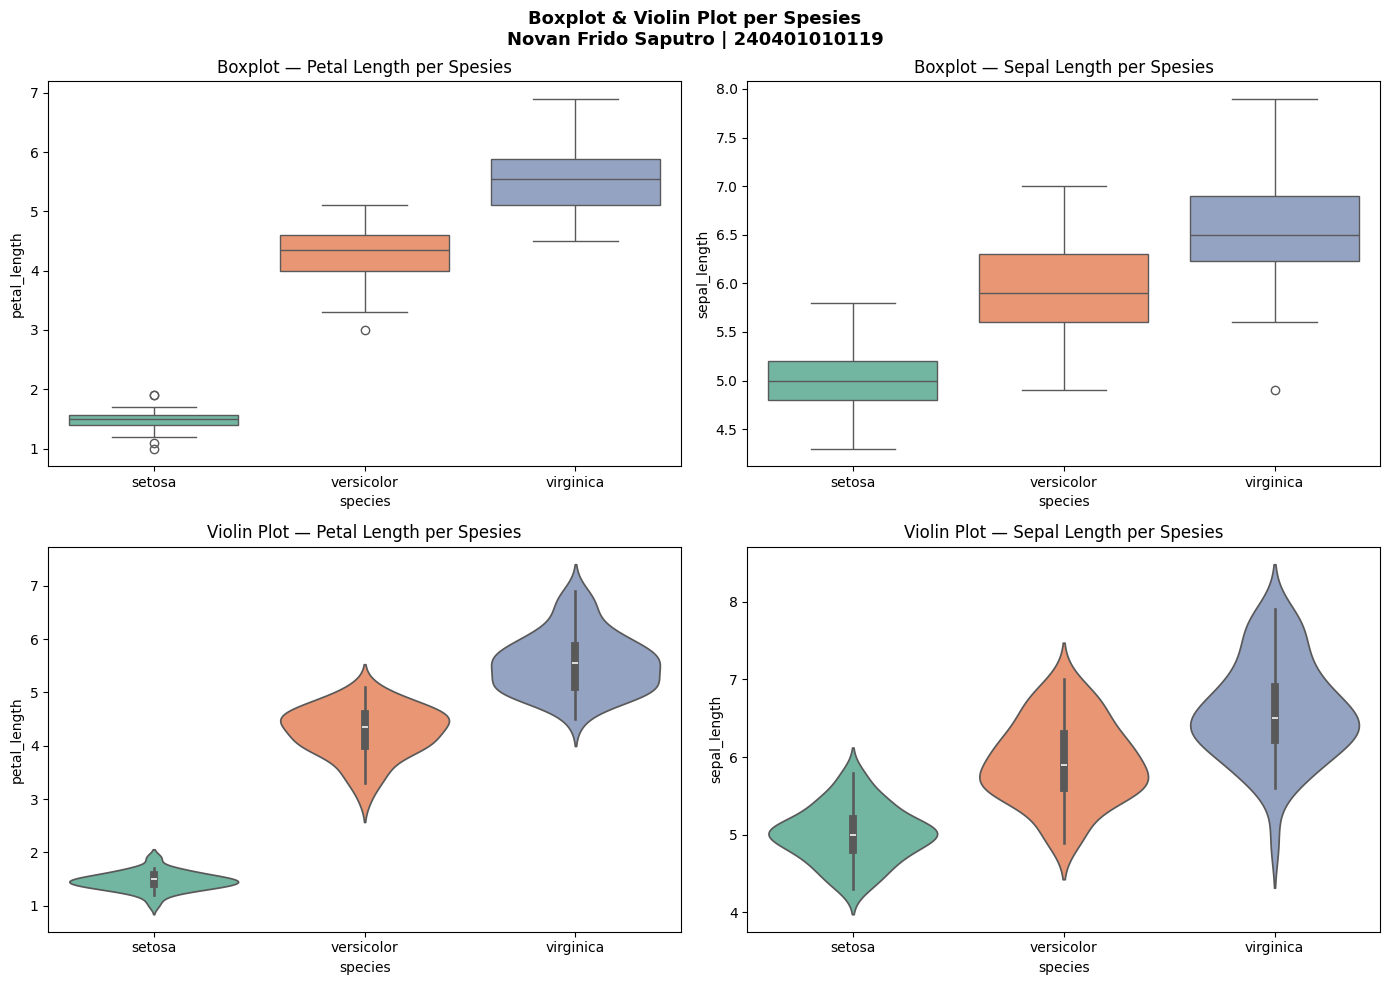


--- Statistik Petal Length per Spesies ---
             mean  median    std  min  max
species                                   
setosa      1.462    1.50  0.174  1.0  1.9
versicolor  4.260    4.35  0.470  3.0  5.1
virginica   5.552    5.55  0.552  4.5  6.9

✅ Grafik disimpan: boxplot_violin_iris.png


In [6]:
print("=" * 55)
print("  LANGKAH 4 — BOXPLOT & VIOLIN PLOT")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Boxplot & Violin Plot per Spesies\n{NAMA} | {NIM}",
             fontsize=13, fontweight='bold')

sns.boxplot(data=df, x='species', y='petal_length',
            palette='Set2', ax=axes[0][0])
axes[0][0].set_title('Boxplot — Petal Length per Spesies')

sns.boxplot(data=df, x='species', y='sepal_length',
            palette='Set2', ax=axes[0][1])
axes[0][1].set_title('Boxplot — Sepal Length per Spesies')

sns.violinplot(data=df, x='species', y='petal_length',
               palette='Set2', inner='box', ax=axes[1][0])
axes[1][0].set_title('Violin Plot — Petal Length per Spesies')

sns.violinplot(data=df, x='species', y='sepal_length',
               palette='Set2', inner='box', ax=axes[1][1])
axes[1][1].set_title('Violin Plot — Sepal Length per Spesies')

plt.tight_layout()
plt.savefig('boxplot_violin_iris.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n--- Statistik Petal Length per Spesies ---")
print(df.groupby('species')['petal_length']
      .agg(['mean','median','std','min','max']).round(3))
print("\n✅ Grafik disimpan: boxplot_violin_iris.png")

In [7]:
print("=" * 55)
print("  LANGKAH 5 — MATRIKS KORELASI")
print("=" * 55)

df_num        = df.drop('species', axis=1)
corr_pearson  = df_num.corr(method='pearson')
corr_spearman = df_num.corr(method='spearman')

print("--- Korelasi Pearson ---")
print(corr_pearson.round(3))
print("\n--- Korelasi Spearman ---")
print(corr_spearman.round(3))

mask        = np.triu(np.ones(corr_pearson.shape, dtype=bool))
corr_masked = corr_pearson.where(~mask)
corr_stack  = corr_masked.stack()
max_pair    = corr_stack.idxmax()
min_pair    = corr_stack.idxmin()

print(f"\n🔴 Korelasi tertinggi : {max_pair[0]} vs {max_pair[1]}"
      f" = {corr_pearson.loc[max_pair]:.3f}")
print(f"🔵 Korelasi terendah  : {min_pair[0]} vs {min_pair[1]}"
      f" = {corr_pearson.loc[min_pair]:.3f}")

x   = df[max_pair[0]]
y   = df[max_pair[1]]
r,   p_r = stats.pearsonr(x, y)
rho, p_s = stats.spearmanr(x, y)

print(f"\n--- Uji Statistik: {max_pair[0]} vs {max_pair[1]} ---")
print(f"  Pearson  r = {r:.4f}  (p = {p_r:.6f})")
print(f"  Spearman ρ = {rho:.4f}  (p = {p_s:.6f})")
print("  ✅ Korelasi signifikan!" if p_r < 0.05
      else "  ⚠️  Tidak signifikan")

  LANGKAH 5 — MATRIKS KORELASI
--- Korelasi Pearson ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

--- Korelasi Spearman ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.167         0.882        0.834
sepal_width         -0.167        1.000        -0.310       -0.289
petal_length         0.882       -0.310         1.000        0.938
petal_width          0.834       -0.289         0.938        1.000

🔴 Korelasi tertinggi : petal_width vs petal_length = 0.963
🔵 Korelasi terendah  : petal_length vs sepal_width = -0.428

--- Uji Statistik: petal_width vs petal_length ---
  Pearson  r = 0.9629  (p = 0.000000)
  Spearman ρ = 0.9377  (p = 0.000000)

  LANGKAH 6 — SCATTER PLOT & HEATMAP KORELASI


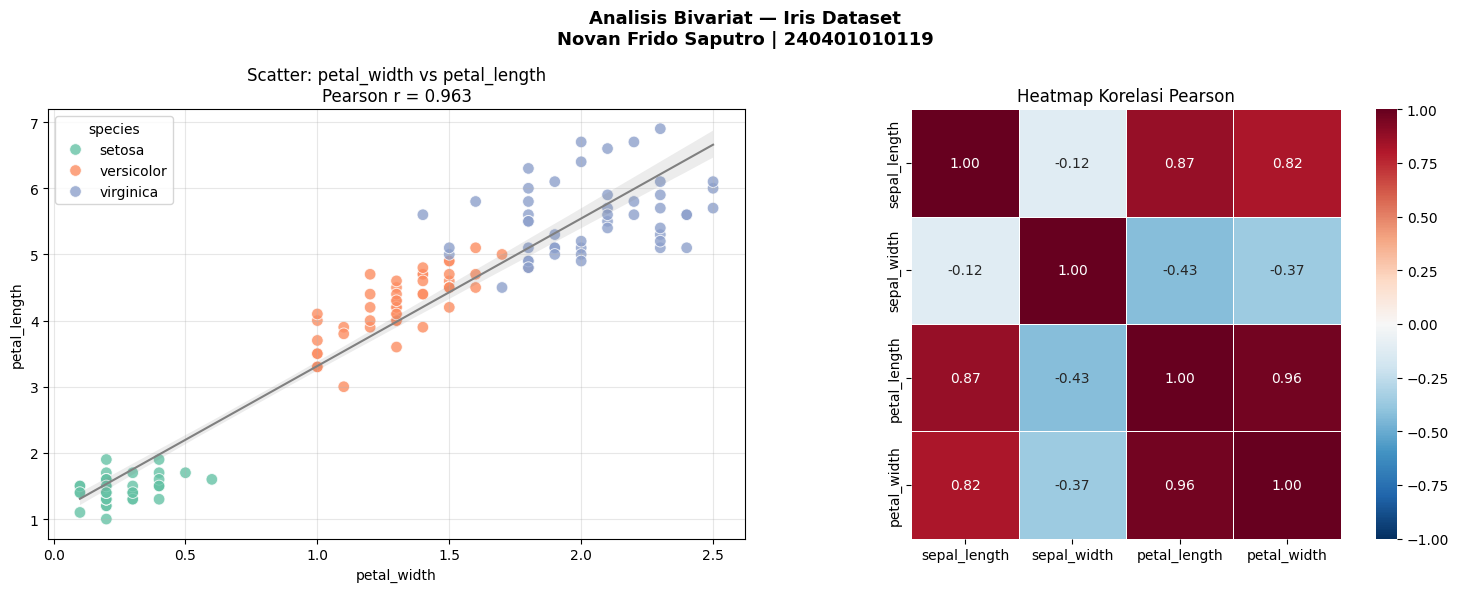

✅ Grafik disimpan: scatter_heatmap_iris.png


In [8]:
print("=" * 55)
print("  LANGKAH 6 — SCATTER PLOT & HEATMAP KORELASI")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Analisis Bivariat — Iris Dataset\n{NAMA} | {NIM}",
             fontsize=13, fontweight='bold')

sns.scatterplot(data=df, x=max_pair[0], y=max_pair[1],
                hue='species', palette='Set2',
                s=70, alpha=0.8, ax=axes[0])
sns.regplot(data=df, x=max_pair[0], y=max_pair[1],
            scatter=False, color='gray',
            line_kws={'linewidth': 1.5}, ax=axes[0])
axes[0].set_title(f'Scatter: {max_pair[0]} vs {max_pair[1]}\n'
                  f'Pearson r = {r:.3f}')
axes[0].grid(True, alpha=0.3)

sns.heatmap(corr_pearson, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            linecolor='white', ax=axes[1])
axes[1].set_title('Heatmap Korelasi Pearson')

plt.tight_layout()
plt.savefig('scatter_heatmap_iris.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: scatter_heatmap_iris.png")

## Kesimpulan — Pertemuan 4: Statistika Dasar & Analisis Data

Statistika selalu terasa abstrak waktu dipelajari secara teori. Tapi di pertemuan ini, dengan dataset Iris yang konkret, semua konsep itu tiba-tiba punya makna yang jauh lebih intuitif.

Yang paling menarik perhatian saya adalah korelasi antara `petal_length` dan `petal_width` yang sangat tinggi, di atas 0.96. Artinya hanya dari panjang kelopak saja kita sudah bisa menduga lebarnya dengan sangat akurat — ini juga jadi sinyal awal bahwa kedua fitur tersebut mungkin redundan jika dipakai bersamaan dalam model ML.

Saya juga mulai memahami skewness dan kurtosis secara intuitif, bukan sekadar rumus. Distribusi yang skewed ke kanan misalnya, memberi tanda bahwa ada nilai-nilai besar yang menarik rata-rata ke atas, sehingga median lebih representatif dari mean. Satu pertanyaan yang masih ingin saya jawab: apakah ada cara formal untuk menguji normalitas distribusi selain melihat histogram secara visual?
